In [1]:
import os
import pystac_client
import planetary_computer
from dotenv import load_dotenv, find_dotenv

# Load environment variables
load_dotenv(find_dotenv(), override=True)

# Note: For Microsoft Planetary Computer, an API Key is optional for basic search.
# If you have one, save it as PC_SDK_SUBSCRIPTION_KEY in your .env file.
pc_api_key = os.getenv("PC_SDK_SUBSCRIPTION_KEY")

def initialize_stac_client(api_key=None):
    """Establish a connection to Microsoft Planetary Computer STAC API"""
    try:
        # The 'modifier' ensures that the links (hrefs) returned by the API
        # are automatically signed with a SAS token for access.
        catalog = pystac_client.Client.open(
            "https://planetarycomputer.microsoft.com/api/stac/v1",
            modifier=planetary_computer.sign_inplace
        )
        
        # Testing connection by accessing the landing page
        if catalog.title:
            print(f"✅ Planetary Computer STAC Client initialized: {catalog.title}")
            return catalog
        else:
            raise Exception("❌ Could not retrieve catalog title.")
            
    except Exception as e:
        raise Exception(f"❌ Connection to STAC API failed: {e}")

# Global catalog object to be used in the next steps (Searching & Loading)
catalog = initialize_stac_client(pc_api_key)

✅ Planetary Computer STAC Client initialized: Microsoft Planetary Computer STAC API


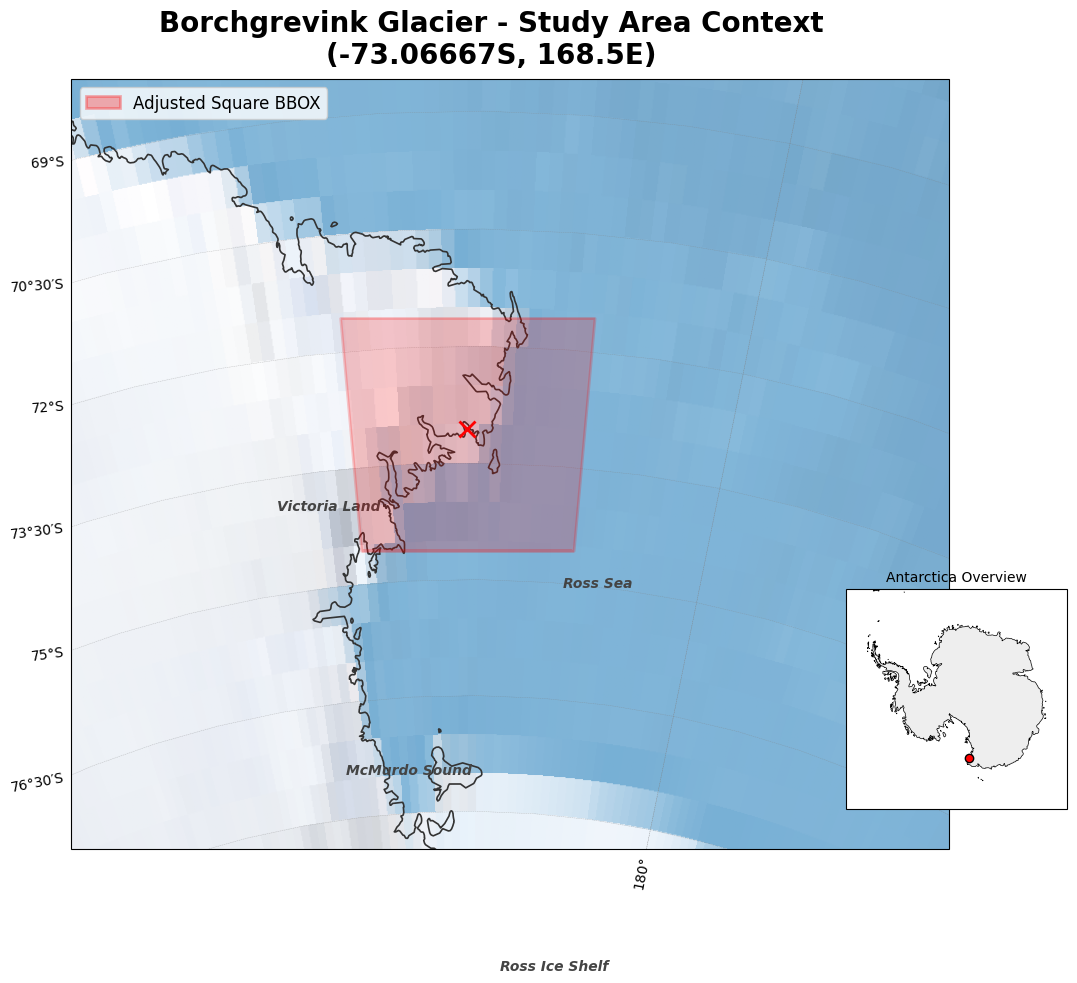

BBOX final para busca STAC: [np.float64(163.34993995893964), -74.56667, np.float64(173.65006004106036), -71.56667]


In [3]:
## 🌍 Define Study Area: Borchgrevink Glacier (With Inset Map & References)

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box
import matplotlib.patches as mpatches
import numpy as np

# --- 1. CONFIGURAÇÕES DE COORDENADAS (QUADRADO REAL) ---
lat_center = -73.06667
lon_center = 168.50000

# Definimos o tamanho desejado em graus de LATITUDE (~1.5 deg ≈ 166 km)
offset_lat = 1.5  

# Compensação da Longitude para manter a forma quadrada na latitude -73°S
cos_lat = np.cos(np.radians(lat_center))
offset_lon = offset_lat / cos_lat

# BBOX final que será usado na busca STAC
bbox = [
    lon_center - offset_lon, # West
    lat_center - offset_lat, # South
    lon_center + offset_lon, # East
    lat_center + offset_lat  # North
]

# --- 2. CONFIGURAÇÃO DA FIGURA PRINCIPAL ---
projection = ccrs.SouthPolarStereo(central_longitude=lon_center)
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=projection)

# Zoom regional focado na Terra de Victoria e Mar de Ross
ax.set_extent([155, 185, -78, -68], ccrs.PlateCarree())

# --- 3. CAMADAS DO MAPA (BASEMAP) ---
ax.stock_img() 
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1.2, edgecolor='#333333')
ax.add_feature(cfeature.OCEAN, facecolor='#e0f3ff', alpha=0.5)
ax.add_feature(cfeature.LAND, facecolor='#ffffff', edgecolor='black')

# Referências Geográficas
references = [
    {'name': 'Ross Sea', 'lat': -75, 'lon': 175},
    {'name': 'Victoria Land', 'lat': -74, 'lon': 162},
    {'name': 'McMurdo Sound', 'lat': -77.5, 'lon': 165},
    {'name': 'Ross Ice Shelf', 'lat': -80, 'lon': 175},
]

for ref in references:
    ax.text(ref['lon'], ref['lat'], ref['name'], transform=ccrs.PlateCarree(),
            fontsize=10, fontweight='bold', ha='center', style='italic', color='#444444')

# Gridlines
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                  linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# --- 4. PLOTAGEM DA ÁREA DE ESTUDO (BBOX) ---
bbox_geom = box(bbox[0], bbox[1], bbox[2], bbox[3])
ax.add_geometries([bbox_geom], crs=ccrs.PlateCarree(),
                  facecolor='red', edgecolor='red',
                  linewidth=2, alpha=0.2, zorder=10)
ax.plot(lon_center, lat_center, 'rx', markersize=12, markeredgewidth=2,
        transform=ccrs.PlateCarree(), zorder=11)

# --- 5. INSET MAP (LOCALIZAÇÃO CONTINENTAL) ---
ax_inset = fig.add_axes([0.7, 0.15, 0.22, 0.22], projection=ccrs.SouthPolarStereo())
ax_inset.set_extent([-180, 180, -90, -60], ccrs.PlateCarree()) 

ax_inset.add_feature(cfeature.LAND, facecolor='#eeeeee')
ax_inset.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax_inset.plot(lon_center, lat_center, 'ro', markersize=6, 
              transform=ccrs.PlateCarree(), markeredgecolor='black')
ax_inset.set_title("Antarctica Overview", fontsize=10)

# --- 6. TÍTULO E LEGENDA ---
plt.suptitle(f'Borchgrevink Glacier - Study Area Context\n({lat_center}S, {lon_center}E)', 
             fontsize=20, fontweight='bold', y=0.95)

bbox_patch = mpatches.Patch(color='red', alpha=0.3, ec='red', lw=2, label='Adjusted Square BBOX')
ax.legend(handles=[bbox_patch], loc='upper left', frameon=True, fontsize=12)

plt.show()

print(f"BBOX final para busca STAC: {bbox}")

In [4]:
import pandas as pd

def search_and_inspect_landsat(catalog, bbox, start_date, end_date):
    """
    Search and inspect Landsat scenes using Planetary Computer STAC API.

    This function:
    1. Queries the STAC API specifically for Landsat Collection 2 Level 2
    2. Uses the provided BBOX and temporal range
    3. Extracts cloud cover and asset links (QA_PIXEL and Data)
    4. Returns a list compatible with the next steps of the pipeline
    """

    # --------------------------------------
    # 🌍 STEP 1 — Define Search Parameters
    # --------------------------------------
    # 'landsat-c2-l2' is the standard collection for Landsat 7, 8, and 9
    time_range = f"{start_date}/{end_date}"

    print("\n🔎 Querying Microsoft Planetary Computer (STAC API)...")
    print(f"BBOX: {bbox}")
    print(f"Time range: {time_range}")

    # --------------------------------------
    # 📡 STEP 2 — Execute Search
    # --------------------------------------
    search = catalog.search(
        collections=["landsat-c2-l2"],
        bbox=bbox,
        datetime=time_range
    )

    items = search.item_collection()
    
    print(f"\n📦 Total entries returned: {len(items)}")

    if len(items) == 0:
        print("⚠️ No data returned from STAC.")
        return []

# --------------------------------------
    # 📦 STEP 3 — Extract Metadata (Items to Scenes)
    # --------------------------------------
    scenes = []

    for item in items:
        # Extração segura dos Assets (objetos pystac.Asset)
        # Verificamos se a chave existe antes de acessar o .href
        assets = item.assets
        
        preview_url = assets["rendered_preview"].href if "rendered_preview" in assets else None
        qa_url = assets["qa_pixel"].href if "qa_pixel" in assets else None

        scene = {
            "id": item.id,
            "title": item.id,
            "date": item.datetime.strftime("%Y-%m-%d"),
            "cloud_cover": item.properties.get("eo:cloud_cover"),
            "satellite": item.properties.get("platform"),
            "download_url": preview_url,
            "qa_pixel_url": qa_url
        }
        scenes.append(scene)

    # --------------------------------------
    # 📊 STEP 4 — Summary & Diagnostics
    # --------------------------------------
    print(f"✅ Final Landsat scenes collected: {len(scenes)}")

    # Display as a clean Table for inspection
    df_temp = pd.DataFrame(scenes)
    if not df_temp.empty:
        print("\n📋 Sample scenes (Top 5):")
        print(df_temp[['date', 'cloud_cover', 'satellite']].head())

    valid_links = sum(1 for s in scenes if s["qa_pixel_url"] is not None)
    print(f"\n🔗 Scenes with QA_PIXEL links: {valid_links}/{len(scenes)}")

    return scenes

# --- Execution ---
# Now we call the function using the 'catalog' from the Setup block
landsat_scenes = search_and_inspect_landsat(
    catalog, 
    bbox, 
    "1980-01-01", 
    "2024-12-31"
)


🔎 Querying Microsoft Planetary Computer (STAC API)...
BBOX: [np.float64(163.34993995893964), -74.56667, np.float64(173.65006004106036), -71.56667]
Time range: 1980-01-01/2024-12-31

📦 Total entries returned: 7014
✅ Final Landsat scenes collected: 7014

📋 Sample scenes (Top 5):
         date  cloud_cover  satellite
0  2024-12-31        98.91  landsat-9
1  2024-12-31       100.00  landsat-9
2  2024-12-30         0.14  landsat-9
3  2024-12-30         0.89  landsat-9
4  2024-12-30         3.68  landsat-9

🔗 Scenes with QA_PIXEL links: 7014/7014


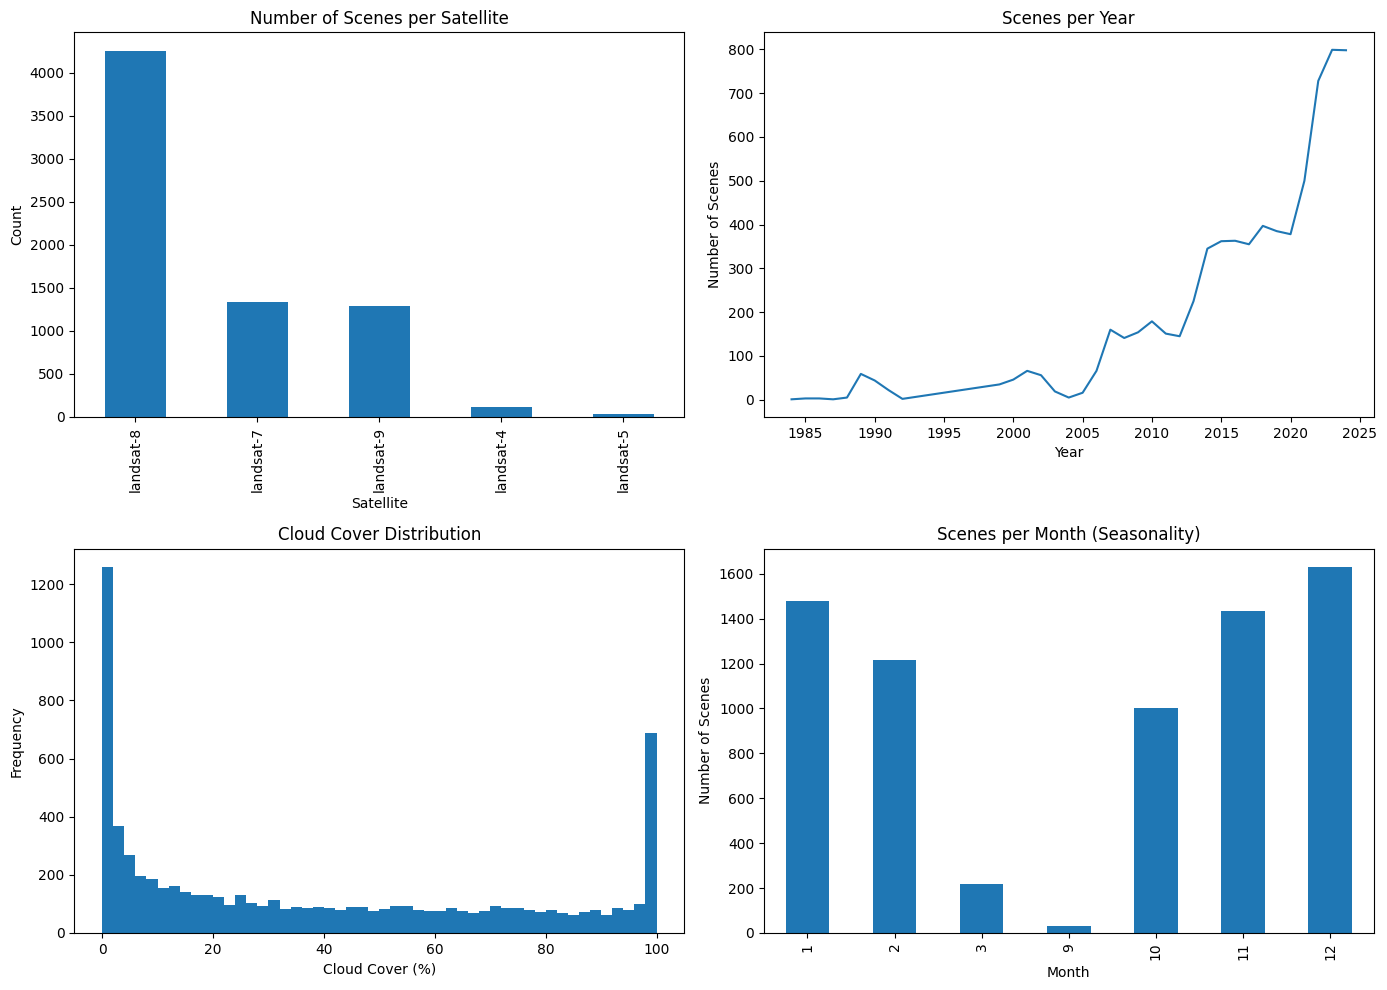

In [ ]:
# ==========================================================
# 📊 Landsat Exploratory Analysis 
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------
# 📦 STEP 1 — Prepare DataFrame
# --------------------------------------
df = pd.DataFrame(landsat_scenes)

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Extract useful fields
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# --------------------------------------
# 📈 STEP 2 — Create Multi-Panel Plot
# --------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --------------------------------------
# 🛰️ 1. Scenes per satellite
# --------------------------------------
df["satellite"].value_counts().plot(kind="bar", ax=axes[0, 0])

axes[0, 0].set_title("Number of Scenes per Satellite")
axes[0, 0].set_xlabel("Satellite")
axes[0, 0].set_ylabel("Count")

# --------------------------------------
# 📅 2. Scenes per year
# --------------------------------------
df["year"].value_counts().sort_index().plot(ax=axes[0, 1])

axes[0, 1].set_title("Scenes per Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Number of Scenes")

# --------------------------------------
# ☁️ 3. Cloud cover distribution
# --------------------------------------
df["cloud_cover"].plot(kind="hist", bins=50, ax=axes[1, 0])

axes[1, 0].set_title("Cloud Cover Distribution")
axes[1, 0].set_xlabel("Cloud Cover (%)")
axes[1, 0].set_ylabel("Frequency")

# --------------------------------------
# 🧊 4. Seasonality (monthly)
# --------------------------------------
df["month"].value_counts().sort_index().plot(kind="bar", ax=axes[1, 1])

axes[1, 1].set_title("Scenes per Month (Seasonality)")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Number of Scenes")

# --------------------------------------
# 🎨 Layout Adjustment
# --------------------------------------
plt.tight_layout()
plt.show()


🧾 Clean Dataset Preview:
                                id                            title  \
0  LC09_L2SR_055113_20241231_02_T2  LC09_L2SR_055113_20241231_02_T2   
1  LC09_L2SR_055112_20241231_02_T2  LC09_L2SR_055112_20241231_02_T2   
2  LC09_L2SR_064113_20241230_02_T2  LC09_L2SR_064113_20241230_02_T2   
3  LC09_L2SR_064112_20241230_02_T2  LC09_L2SR_064112_20241230_02_T2   
4  LC09_L2SR_064111_20241230_02_T2  LC09_L2SR_064111_20241230_02_T2   

        date  cloud_cover  satellite  \
0 2024-12-31        98.91  landsat-9   
1 2024-12-31       100.00  landsat-9   
2 2024-12-30         0.14  landsat-9   
3 2024-12-30         0.89  landsat-9   
4 2024-12-30         3.68  landsat-9   

                                        download_url  \
0  https://planetarycomputer.microsoft.com/api/da...   
1  https://planetarycomputer.microsoft.com/api/da...   
2  https://planetarycomputer.microsoft.com/api/da...   
3  https://planetarycomputer.microsoft.com/api/da...   
4  https://planetarycomput

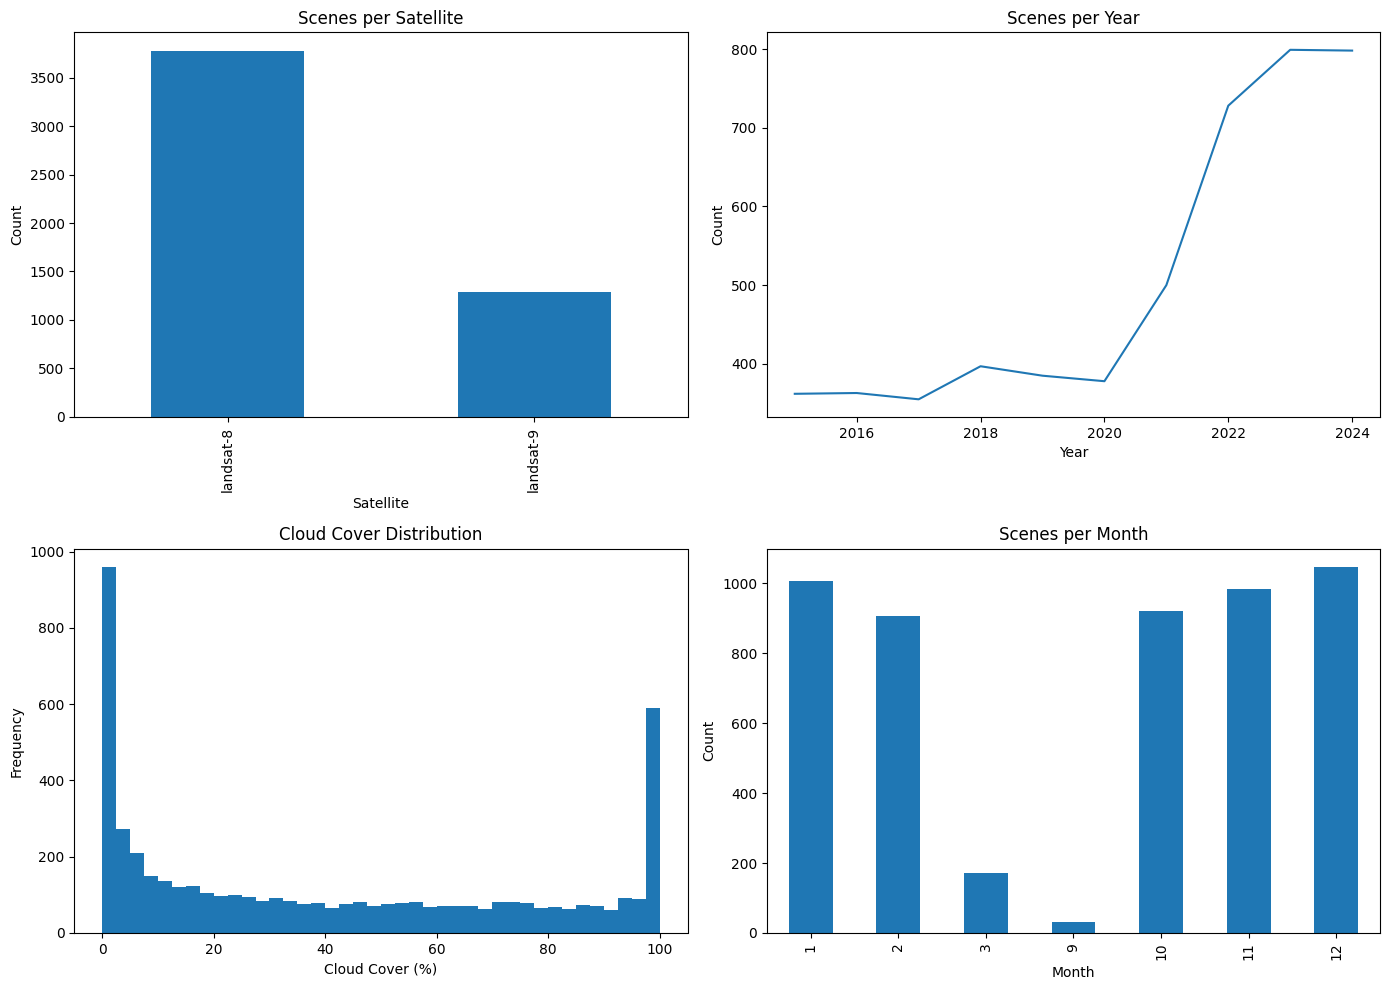

In [9]:
# ==========================================================
# 🧊  Filtering (Clean Dataset)
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------
# 📦 STEP 1 — Load and Prepare DataFrame
# --------------------------------------
df = pd.DataFrame(landsat_scenes)

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Extract temporal components
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# --------------------------------------
# 🎯 STEP 2 — Apply Scientific Filtering
# --------------------------------------
# Criteria:
# - Use reliable period (Landsat 8/9 era)
# - Keep only main sensors
# - Remove extreme cloud outliers if needed

df_filtered = df[
    (df["year"] >= 2015) &
    (df["satellite"].isin(["landsat-8", "landsat-9"])) &
    (df["cloud_cover"].notnull())
].copy()

# --------------------------------------
# ☁️ STEP 3 — Classify Cloud Cover Groups
# --------------------------------------
def classify_cloud_group(cloud):
    if cloud < 10:
        return "Low (Clear)"
    elif cloud <= 50:
        return "Medium (Mixed)"
    elif cloud > 80:
        return "High (Cloudy)"
    else:
        return "Transition"

df_filtered["cloud_group"] = df_filtered["cloud_cover"].apply(classify_cloud_group)


# --------------------------------------
# 📊 STEP 4 — Display Clean Dataset Preview
# --------------------------------------
print("\n🧾 Clean Dataset Preview:")
print(df_filtered.head())

print(f"\n📦 Total filtered scenes: {len(df_filtered)}")

# --------------------------------------
# 📈 STEP 5 — Plot All Graphs (Single Figure)
# --------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 🛰️ 1. Scenes per satellite
df_filtered["satellite"].value_counts().plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Scenes per Satellite")
axes[0, 0].set_xlabel("Satellite")
axes[0, 0].set_ylabel("Count")

# 📅 2. Scenes per year
df_filtered["year"].value_counts().sort_index().plot(ax=axes[0, 1])
axes[0, 1].set_title("Scenes per Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Count")

# ☁️ 3. Cloud cover distribution
df_filtered["cloud_cover"].plot(kind="hist", bins=40, ax=axes[1, 0])
axes[1, 0].set_title("Cloud Cover Distribution")
axes[1, 0].set_xlabel("Cloud Cover (%)")
axes[1, 0].set_ylabel("Frequency")

# 🧊 4. Seasonality (monthly)
df_filtered["month"].value_counts().sort_index().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Scenes per Month")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()